### Image Processing and Analysis 2nd Assignment
In this notebook, classical machine-learning models and CNN-based deep-learning models are developed and compared for a binary image-classification task.

The project is based on the kaggle dataset found in this link: https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia

The task is to develop models capable of distinguishing healthy individuals from patients with pneumonia based on X-ray images of patients' lungs. 

The notebook runs when the chest_xray folder and its subfolders containing the image data are both and the notebook itself are under the same folder directory.

In [1]:
# Imports
import time

notebook_start = time.perf_counter()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import skimage
import sklearn
import torch
import torchvision
from pathlib import Path
import joblib


print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("OpenCV:", cv2.__version__)
print("scikit-image:", skimage.__version__)
print("scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

NumPy: 2.5.2
Pandas: 3.0.5
OpenCV: 5.0.0
scikit-image: 0.26.0
scikit-learn: 1.9.1
PyTorch: 2.14.0+cpu
Torchvision: 0.29.0+cpu


The following block of code organises the image data, performs exploratory data analysis (EDA), classifies the images according to their labels, and provides information about class distributions across the dataset splits.

Initially, the dataset contains three classes: Normal, bacterial pneumonia, and viral pneumonia. The image classification problem can therefore be approached in several ways. For example, binary classifiers could be developed to distinguish healthy from pneumonia cases, or bacterial from viral pneumonia. Alternatively, the problem could be formulated as a three-class classification task.

However, the original validation split contains no viral cases. Therefore, it is not suitable for evaluating a classification task involving the viral class without additional preprocessing or a custom validation strategy. Furthermore, including the viral images would increase the computational requirements of the project. For these reasons, the main focus of this notebook is binary classification of normal versus bacterial pneumonia images.

The notebook subsequently implements two modelling approaches. Three classical machine-learning models are trained using hand-crafted image features, while three basic CNN architectures are trained directly on the whole images. The models are evaluated using appropriate performance metrics, and the best-performing model from each approach is subsequently compared.

The second CNN architecture, which incorporates regularisation through Batch Normalisation and Dropout layers, achieved better performance than the best-performing classical model, an SVM.

In [2]:
# ============================================================
# 1. Dataset location
# ============================================================

DATA_DIR = Path("chest_xray")

SPLITS = ["train", "val", "test"]

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png"
}


# ============================================================
# 2. Classify images
# ============================================================

def classify_image(image_path):
    """
    Assign a class to an image based on its folder and filename.

    NORMAL:
        Images inside the NORMAL directory.

    BACTERIAL:
        Images inside PNEUMONIA whose filename contains 'bacteria'.

    VIRAL:
        Images inside PNEUMONIA whose filename contains 'virus'.

    UNKNOWN:
        An image file that cannot be classified.
    """

    parent_folder = image_path.parent.name.upper()
    filename = image_path.name.lower()

    # Normal X-rays
    if parent_folder == "NORMAL":
        return "NORMAL"

    # Pneumonia X-rays
    if parent_folder == "PNEUMONIA":

        if "bacteria" in filename:
            return "BACTERIAL"

        elif "virus" in filename:
            return "VIRAL"

        else:
            return "UNKNOWN"

    return "UNKNOWN"


# ============================================================
# 3. Scan the dataset
# ============================================================

records = []

for split in SPLITS:

    split_dir = DATA_DIR / split

    for class_dir in split_dir.iterdir():

        if not class_dir.is_dir():
            continue

        for image_path in class_dir.iterdir():

            # Ignore files that aren't images
            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue

            label = classify_image(image_path)

            records.append({
                "split": split,
                "original_folder": class_dir.name,
                "label": label,
                "filename": image_path.name,
                "path": str(image_path)
            })


# Convert to DataFrame
df = pd.DataFrame(records)


# ============================================================
# 4. Overall dataset
# ============================================================

print("=" * 60)
print("OVERALL DATASET")
print("=" * 60)

print(f"\nTotal images: {len(df):,}")

print("\nClass counts:")
print(df["label"].value_counts())

print("\nClass percentages:")
print(
    (df["label"].value_counts(normalize=True) * 100)
    .round(2)
)


# ============================================================
# 5. Class counts by split
# ============================================================

print("\n" + "=" * 60)
print("CLASS COUNTS BY SPLIT")
print("=" * 60)

counts_by_split = pd.crosstab(
    df["split"],
    df["label"]
)

print(counts_by_split)


# ============================================================
# 6. Class percentages by split
# ============================================================

print("\n" + "=" * 60)
print("CLASS PERCENTAGES BY SPLIT")
print("=" * 60)

percentages_by_split = (
    pd.crosstab(
        df["split"],
        df["label"],
        normalize="index"
    ) * 100
)

print(percentages_by_split.round(2))


# ============================================================
# 7. Check for unknown IMAGE files
# ============================================================

unknown = df[df["label"] == "UNKNOWN"]

print("\n" + "=" * 60)
print("UNKNOWN IMAGE FILES")
print("=" * 60)

print(f"\nNumber of unknown image files: {len(unknown)}")

if len(unknown) > 0:

    print("\nUnknown images:")

    print(
        unknown[
            ["split", "original_folder", "filename"]
        ].to_string(index=False)
    )


# ============================================================
# 8. Pneumonia subtype counts
# ============================================================

pneumonia_df = df[
    df["original_folder"].str.upper() == "PNEUMONIA"
]

print("\n" + "=" * 60)
print("PNEUMONIA SUBTYPES BY SPLIT")
print("=" * 60)

pneumonia_counts = pd.crosstab(
    pneumonia_df["split"],
    pneumonia_df["label"]
)

print(pneumonia_counts)


# ============================================================
# 9. Create the final binary dataset
# ============================================================

binary_df = df[
    df["label"].isin([
        "NORMAL",
        "BACTERIAL"
    ])
].copy()


print("\n" + "=" * 60)
print("FINAL BINARY DATASET")
print("NORMAL vs BACTERIAL")
print("=" * 60)

binary_counts = pd.crosstab(
    binary_df["split"],
    binary_df["label"]
)

print(binary_counts)


# ============================================================
# 10. Binary class percentages by split
# ============================================================

print("\n" + "=" * 60)
print("BINARY CLASS PERCENTAGES BY SPLIT")
print("=" * 60)

binary_percentages = (
    pd.crosstab(
        binary_df["split"],
        binary_df["label"],
        normalize="index"
    ) * 100
)

print(binary_percentages.round(2))


# ============================================================
# 11. Class imbalance ratio
# ============================================================

print("\n" + "=" * 60)
print("CLASS IMBALANCE RATIO")
print("=" * 60)

for split in SPLITS:

    split_data = binary_df[
        binary_df["split"] == split
    ]

    class_counts = split_data["label"].value_counts()

    normal_count = class_counts.get("NORMAL", 0)
    bacterial_count = class_counts.get("BACTERIAL", 0)

    print(f"\n{split.upper()}")

    print(f"  NORMAL:    {normal_count:,}")
    print(f"  BACTERIAL: {bacterial_count:,}")

    if normal_count > 0 and bacterial_count > 0:

        majority = max(
            normal_count,
            bacterial_count
        )

        minority = min(
            normal_count,
            bacterial_count
        )

        ratio = majority / minority

        print(
            f"  Imbalance ratio: {ratio:.2f}:1"
        )

        if normal_count > bacterial_count:
            print("  Majority class: NORMAL")

        elif bacterial_count > normal_count:
            print("  Majority class: BACTERIAL")

        else:
            print("  Classes are perfectly balanced")


# ============================================================
# 12. Final dataset summary
# ============================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(
    f"\nImages retained for binary classification: "
    f"{len(binary_df):,}"
)

print(
    f"NORMAL:    "
    f"{(binary_df['label'] == 'NORMAL').sum():,}"
)

print(
    f"BACTERIAL: "
    f"{(binary_df['label'] == 'BACTERIAL').sum():,}"
)

print(
    "\nViral images excluded from the binary dataset: "
    f"{(df['label'] == 'VIRAL').sum():,}"
)

OVERALL DATASET

Total images: 5,856

Class counts:
label
BACTERIAL    2780
NORMAL       1583
VIRAL        1493
Name: count, dtype: int64

Class percentages:
label
BACTERIAL    47.47
NORMAL       27.03
VIRAL        25.50
Name: proportion, dtype: float64

CLASS COUNTS BY SPLIT
label  BACTERIAL  NORMAL  VIRAL
split                          
test         242     234    148
train       2530    1341   1345
val            8       8      0

CLASS PERCENTAGES BY SPLIT
label  BACTERIAL  NORMAL  VIRAL
split                          
test       38.78   37.50  23.72
train      48.50   25.71  25.79
val        50.00   50.00   0.00

UNKNOWN IMAGE FILES

Number of unknown image files: 0

PNEUMONIA SUBTYPES BY SPLIT
label  BACTERIAL  VIRAL
split                  
test         242    148
train       2530   1345
val            8      0

FINAL BINARY DATASET
NORMAL vs BACTERIAL
label  BACTERIAL  NORMAL
split                   
test         242     234
train       2530    1341
val            8       8

BIN

In [3]:
# Display the number of NORMAL and BACTERIAL images in each dataset split
print(pd.crosstab(binary_df["split"], binary_df["label"]))

# Display the percentage of each class within each dataset split
print((pd.crosstab(binary_df["split"], binary_df["label"], normalize="index") * 100).round(2))

label  BACTERIAL  NORMAL
split                   
test         242     234
train       2530    1341
val            8       8
label  BACTERIAL  NORMAL
split                   
test       50.84   49.16
train      65.36   34.64
val        50.00   50.00


In [4]:
# Split Data
original_train = binary_df[binary_df["split"] == "train"].copy()
test_df = binary_df[binary_df["split"] == "test"].copy()

from sklearn.model_selection import train_test_split

model_train_df, model_val_df = train_test_split(
    original_train,
    test_size=0.20,
    stratify=original_train["label"],
    random_state=42
)

print(model_train_df["label"].value_counts())
print(model_val_df["label"].value_counts())

label
BACTERIAL    2023
NORMAL       1073
Name: count, dtype: int64
label
BACTERIAL    507
NORMAL       268
Name: count, dtype: int64


The code block above separates the data into training, validation and test sets. These sets are not yet ready for model training and testing because they still contain metadata about the image paths.

In the following code blocks, two functions are defined to create the model-usable datasets that only contain the raw images. Subsequently, these datasets are inspected for their dimensions (number of images, height, width).

In [5]:
# Define image load function
def load_image(image_path, size=(224, 224)):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    image = cv2.resize(image, size)
    image = image.astype("float32") / 255.0
    
    return image

# Define usable dataset creation function
import numpy as np

def create_image_dataset(df):
    images = []
    labels = []

    for _, row in df.iterrows():
        image = load_image(row["path"])
        
        images.append(image)
        labels.append(row["label"])

    return np.array(images), np.array(labels) 

In [6]:
X_train, y_train = create_image_dataset(model_train_df)
X_val, y_val = create_image_dataset(model_val_df)
X_test, y_test = create_image_dataset(test_df)

print(X_train.dtype)
print(X_train.min(), X_train.max())

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

float32
0.0 1.0
X_train: (3096, 224, 224)
y_train: (3096,)
X_val: (775, 224, 224)
y_val: (775,)
X_test: (476, 224, 224)
y_test: (476,)


In the following two blocks, one encodes the image labels for model training and the other plots images with the original labeling for visualisation purposes. From this visualisation, even the human eye we can detect some differences between the classes, i.e. the pneumonia images appear a little more blurry. 

In [7]:
# Map classes to encoded labels (int32 is also appropriate for CNNs)
label_mapping = {
    "NORMAL": 0,
    "BACTERIAL": 1
}

y_train = model_train_df["label"].map(label_mapping).to_numpy(dtype=np.int32)
y_val = model_val_df["label"].map(label_mapping).to_numpy(dtype=np.int32)
y_test = test_df["label"].map(label_mapping).to_numpy(dtype=np.int32)


# Check labelling
print("Training labels:")
print(y_train.dtype, np.unique(y_train, return_counts=True))

print("\nValidation labels:")
print(y_val.dtype, np.unique(y_val, return_counts=True))

print("\nTest labels:")
print(y_test.dtype, np.unique(y_test, return_counts=True))

Training labels:
int32 (array([0, 1], dtype=int32), array([1073, 2023]))

Validation labels:
int32 (array([0, 1], dtype=int32), array([268, 507]))

Test labels:
int32 (array([0, 1], dtype=int32), array([234, 242]))


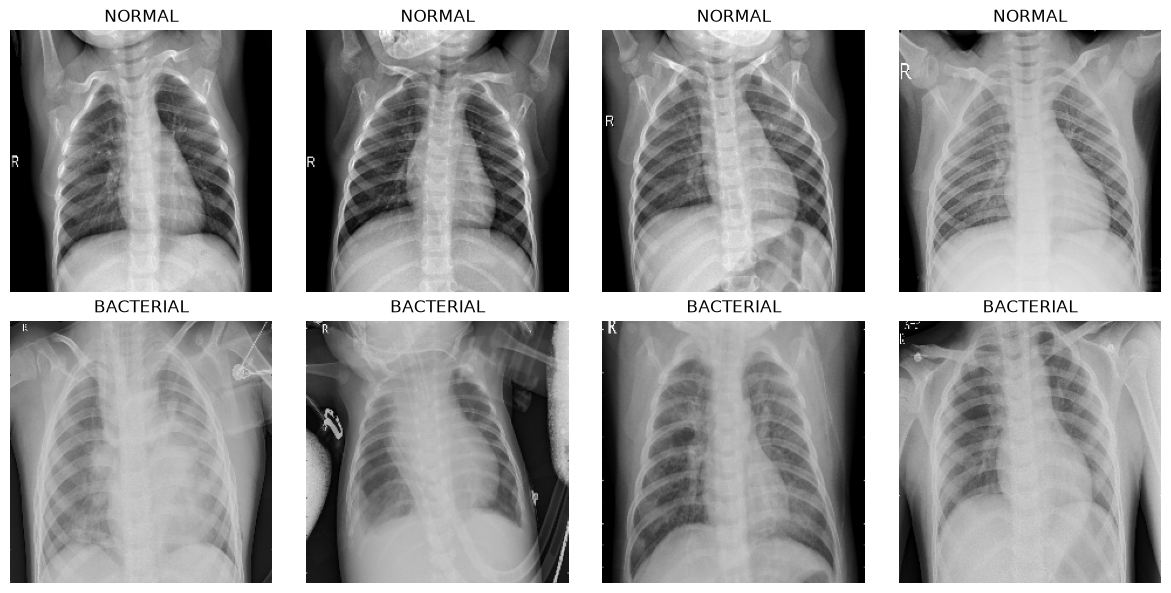

In [8]:
normal_idx = np.where(y_train == 0)[0]
bacterial_idx = np.where(y_train == 1)[0]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, idx in enumerate(normal_idx[:4]):
    axes[0, i].imshow(X_train[idx], cmap="gray")
    axes[0, i].set_title("NORMAL")
    axes[0, i].axis("off")

for i, idx in enumerate(bacterial_idx[:4]):
    axes[1, i].imshow(X_train[idx], cmap="gray")
    axes[1, i].set_title("BACTERIAL")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

### Classical Model Approach

The following eight blocks of code demonstrate the workflow used for training and evaluating the classical machine-learning models. Three classical models were trained: Logistic Regression (LR), Support Vector Machine (SVM), and Random Forest (RF). LR was selected as a simple linear baseline, while SVM and RF were selected as established classical approaches that can model more complex relationships between hand-crafted image features. Together, they provide a comparison between a linear classifier, a kernel-based classifier, and a nonlinear tree-based ensemble.

Initially, all three models were trained using a small set of hand-crafted intensity-based features. This was motivated by the visual differences in image intensity observed between the classes during the exploratory analysis. However, the accuracy of none of the models exceeded 85%, suggesting that intensity information alone was insufficient to adequately distinguish the classes.

Additional spatial features were therefore incorporated to capture information about the distribution and location of pixel intensities within the images. Following their inclusion, all three models achieved validation accuracies above 90%, while differences in the other evaluation metrics between the models remained relatively small.

The models were subsequently trained using the combined intensity and spatial feature set and evaluated on the validation set. SVM achieved a slightly higher ROC-AUC than the other models and was therefore selected for subsequent hyperparameter tuning. The tuned SVM was then evaluated on the independent hold-out test set to obtain the final performance estimate.


In [9]:
def extract_intensity_features(images):
    feature_names = [
        "mean_intensity",
        "std_intensity",
        "median_intensity",
        "min_intensity",
        "max_intensity",
        "q25_intensity",
        "q75_intensity"
    ]

    features = []

    for image in images:
        image_features = [
            np.mean(image),
            np.std(image),
            np.median(image),
            np.min(image),
            np.max(image),
            np.percentile(image, 25),
            np.percentile(image, 75)
        ]

        features.append(image_features)

    return np.array(features), feature_names

X_train_intensity, intensity_feature_names = extract_intensity_features(X_train)
X_val_intensity, _ = extract_intensity_features(X_val)
X_test_intensity, _ = extract_intensity_features(X_test)

print("Training features:", X_train_intensity.shape)
print("Validation features:", X_val_intensity.shape)
print("Test features:", X_test_intensity.shape)

Training features: (3096, 7)
Validation features: (775, 7)
Test features: (476, 7)


In [10]:
# Imports and model creation 
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

classical_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

In [11]:
# Cross-validation
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = []

for name, model in classical_models.items():

    scores = cross_validate(
        model,
        X_train_intensity,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(results)

print(results_df.round(3))

                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
0  Logistic Regression     0.803      0.917   0.769  0.836    0.887
1                  SVM     0.837      0.948   0.794  0.864    0.923
2        Random Forest     0.834      0.911   0.827  0.866    0.909



Logistic Regression
[[225  43]
 [111 396]]


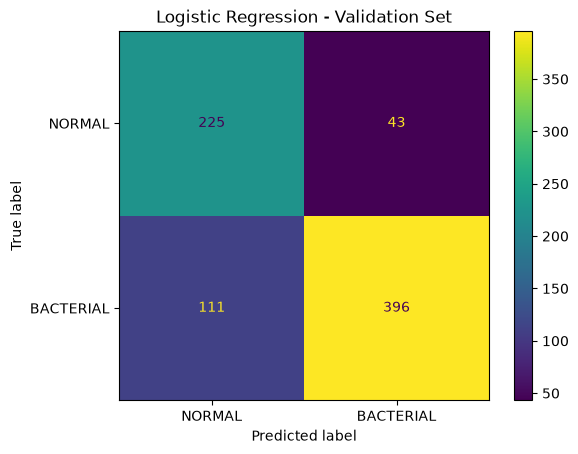

c:\Users\kosta\Documents\MSc\ImageProcessing\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



SVM
[[241  27]
 [ 92 415]]


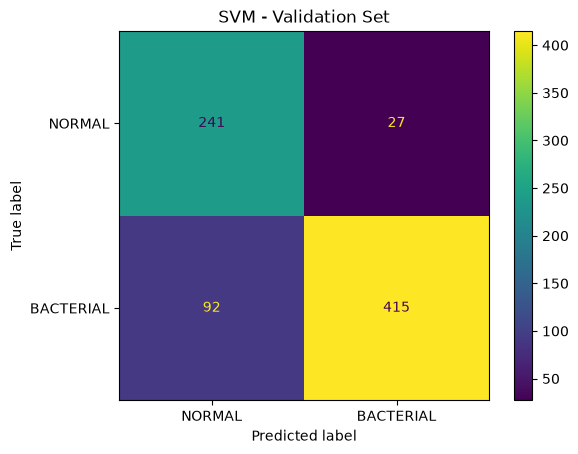


Random Forest
[[220  48]
 [ 70 437]]


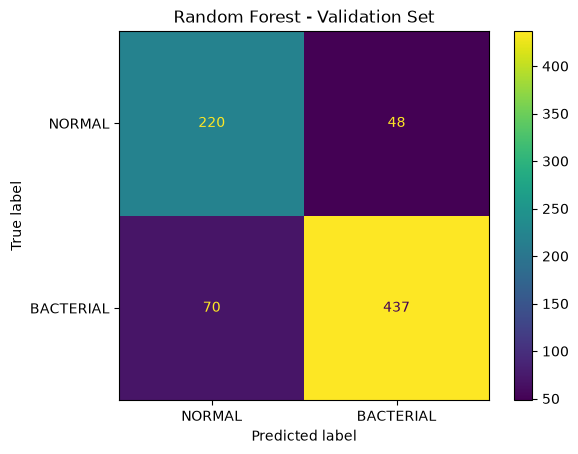


Validation Results:
                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
0  Logistic Regression     0.801      0.902   0.781  0.837    0.872
1                  SVM     0.846      0.939   0.819  0.875    0.928
2        Random Forest     0.848      0.901   0.862  0.881    0.903


In [12]:
# Train on the whole training data
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Store the validation results for each model
validation_results = []


# Loop through Logistic Regression, SVM, and Random Forest
for name, model in classical_models.items():

    model.fit(
        X_train_intensity,
        y_train
    )

    y_val_pred = model.predict(X_val_intensity)



    if hasattr(model, "predict_proba"):
        y_val_score = model.predict_proba(X_val_intensity)[:, 1]

    else:
        y_val_score = model.decision_function(X_val_intensity)


    
    # Calculate performance on the held-out validation set.    
    validation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1": f1_score(y_val, y_val_pred),
        "ROC-AUC": roc_auc_score(y_val, y_val_score)
    })


    # Confusion Matrix
    cm = confusion_matrix(
        y_val,
        y_val_pred
    )

    print(f"\n{name}")
    print(cm)


    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["NORMAL", "BACTERIAL"]
    )

    disp.plot()

    plt.title(f"{name} - Validation Set")
    plt.show()


# Convert all validation results into a DataFrame
validation_results_df = pd.DataFrame(validation_results)


print("\nValidation Results:")
print(validation_results_df.round(3))

In [13]:
# Extract Spatial features
def extract_spatial_features(images, grid_size=(4, 4)):
    """
    Divide each image into a grid and calculate
    mean and standard deviation for each region.
    """

    features = []
    feature_names = []

    rows, cols = grid_size

    # Create feature names once
    for r in range(rows):
        for c in range(cols):
            feature_names.append(f"region_{r}_{c}_mean")
            feature_names.append(f"region_{r}_{c}_std")

    for image in images:

        image_features = []

        height, width = image.shape

        region_height = height // rows
        region_width = width // cols

        for r in range(rows):
            for c in range(cols):

                y_start = r * region_height
                y_end = (r + 1) * region_height

                x_start = c * region_width
                x_end = (c + 1) * region_width

                region = image[
                    y_start:y_end,
                    x_start:x_end
                ]

                image_features.extend([
                    np.mean(region),
                    np.std(region)
                ])

        features.append(image_features)

    return np.array(features), feature_names

X_train_spatial, spatial_feature_names = extract_spatial_features(X_train)
X_val_spatial, _ = extract_spatial_features(X_val)
X_test_spatial, _ = extract_spatial_features(X_test)

print("Training spatial features:", X_train_spatial.shape)
print("Validation spatial features:", X_val_spatial.shape)
print("Test spatial features:", X_test_spatial.shape)

print("Number of spatial features:", len(spatial_feature_names))

Training spatial features: (3096, 32)
Validation spatial features: (775, 32)
Test spatial features: (476, 32)
Number of spatial features: 32


In [14]:
# Combine datasets
X_train_combined = np.hstack([
    X_train_intensity,
    X_train_spatial
])

X_val_combined = np.hstack([
    X_val_intensity,
    X_val_spatial
])

X_test_combined = np.hstack([
    X_test_intensity,
    X_test_spatial
])

print("Training:", X_train_combined.shape)
print("Validation:", X_val_combined.shape)
print("Test:", X_test_combined.shape)

Training: (3096, 39)
Validation: (775, 39)
Test: (476, 39)


In [15]:
# Cross-Validation with spatial features included
spatial_results = []

for name, model in classical_models.items():

    scores = cross_validate(
        model,
        X_train_combined,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    spatial_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

spatial_results_df = pd.DataFrame(spatial_results)

print(spatial_results_df.round(3))

                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
0  Logistic Regression     0.949      0.976   0.945  0.960    0.989
1                  SVM     0.959      0.980   0.956  0.968    0.993
2        Random Forest     0.938      0.955   0.949  0.952    0.984



Logistic Regression
[[251  17]
 [ 23 484]]


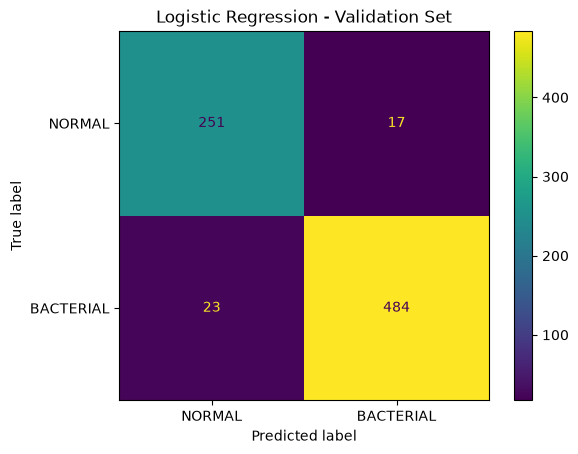

c:\Users\kosta\Documents\MSc\ImageProcessing\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



SVM
[[254  14]
 [ 12 495]]


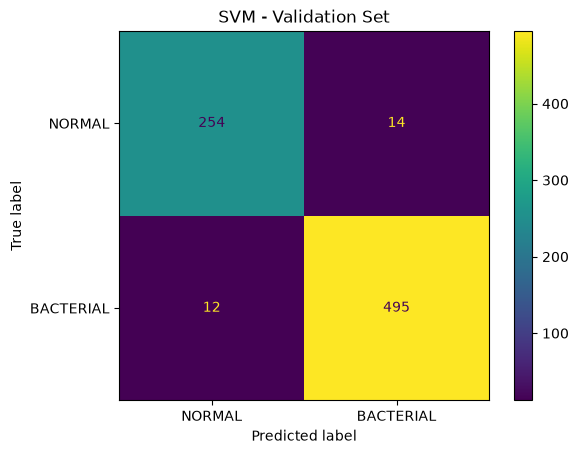


Random Forest
[[241  27]
 [ 15 492]]


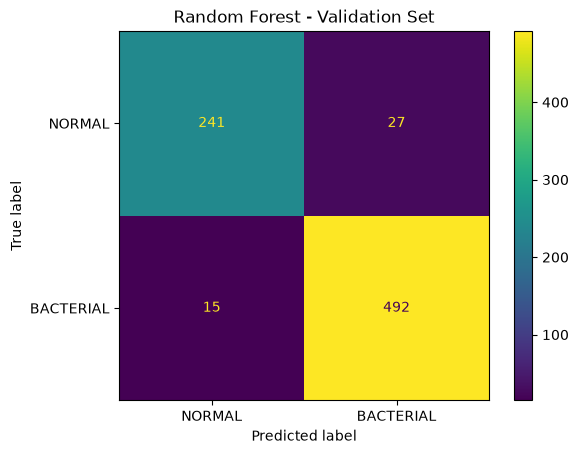


Validation Results - Global + Spatial Features:
                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
0  Logistic Regression     0.948      0.966   0.955  0.960    0.988
1                  SVM     0.966      0.972   0.976  0.974    0.993
2        Random Forest     0.946      0.948   0.970  0.959    0.983


In [16]:
# Final validation of combined feature datasets
validation_spatial_results = []

for name, model in classical_models.items():

    model.fit(X_train_combined, y_train)

    y_val_pred = model.predict(X_val_combined)

    if hasattr(model, "predict_proba"):
        y_val_score = model.predict_proba(X_val_combined)[:, 1]
    else:
        y_val_score = model.decision_function(X_val_combined)

    validation_spatial_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1": f1_score(y_val, y_val_pred),
        "ROC-AUC": roc_auc_score(y_val, y_val_score)
    })

    cm = confusion_matrix(y_val, y_val_pred)

    print(f"\n{name}")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["NORMAL", "BACTERIAL"]
    )

    disp.plot()
    plt.title(f"{name} - Validation Set")
    plt.show()


validation_spatial_results_df = pd.DataFrame(
    validation_spatial_results
)

print("\nValidation Results - Global + Spatial Features:")
print(validation_spatial_results_df.round(3))

In the final classical-model stage, the SVM was hyperparameter-tuned and evaluated on the independent hold-out test set. Although ROC-AUC remained high, test accuracy decreased from 96% on the validation set to 80%. However, the model maintained very high recall (97.9%), meaning that it correctly identified almost all bacterial pneumonia cases, at the cost of a relatively high number of false positives. This suggests that further feature engineering could potentially improve the model's generalisation and reduce false-positive predictions.

In [17]:
# Hyperparameter tuning of SVM
from sklearn.model_selection import GridSearchCV

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True
    ))
])

param_grid = {
    "classifier__C": [0.1, 1, 10, 100],
    "classifier__gamma": ["scale", 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train_combined, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

c:\Users\kosta\Documents\MSc\ImageProcessing\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best parameters:
{'classifier__C': 10, 'classifier__gamma': 0.01}

Best CV ROC-AUC:
0.9940153892662323


In [18]:
# Final Classical model evaluation
best_model = grid_search.best_estimator_

X_train_final = np.vstack([
    X_train_combined,
    X_val_combined
])

y_train_final = np.concatenate([
    y_train,
    y_val
])

best_model.fit(
    X_train_final,
    y_train_final
)

y_test_pred = best_model.predict(X_test_combined)

y_test_score = best_model.predict_proba(
    X_test_combined
)[:, 1]

print("Final Test Performance")
print("----------------------")

print("Accuracy:",
      accuracy_score(y_test, y_test_pred))

print("Precision:",
      precision_score(y_test, y_test_pred))

print("Recall:",
      recall_score(y_test, y_test_pred))

print("F1:",
      f1_score(y_test, y_test_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, y_test_score))

c:\Users\kosta\Documents\MSc\ImageProcessing\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Final Test Performance
----------------------
Accuracy: 0.8004201680672269
Precision: 0.7247706422018348
Recall: 0.9793388429752066
F1: 0.8330404217926186
ROC-AUC: 0.9656353747262839


[[144  90]
 [  5 237]]


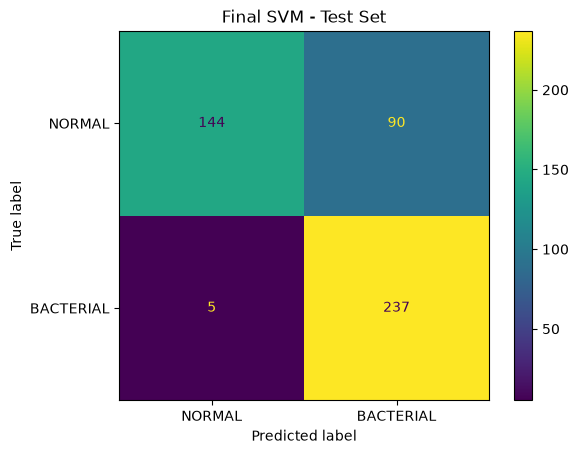

In [19]:
# Final classical model confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "BACTERIAL"]
)

disp.plot()
plt.title("Final SVM - Test Set")
plt.show()

### Deep Learning Approach

For the deep-learning part of the project, three different CNN architectures were evaluated. The first served as a baseline CNN using Convolution and MaxPooling layers. The second was a regularised CNN that additionally incorporated Normalisation and Dropout layers, while the third was a deeper version of the baseline CNN. The motivation for testing these architectures was to investigate whether regularisation and increased network depth improve classification performance when distinguishing between the two classes.

In [20]:
# Imports
import tensorflow as tf
from tensorflow.keras import models as keras_models, layers

In [21]:
# Get the raw image data 
X_train, _ = create_image_dataset(model_train_df)
X_val, _ = create_image_dataset(model_val_df)
X_test, _ = create_image_dataset(test_df)

# Make datasets compatible with CNN input (features, height, width, channels) 
X_train = X_train[...,np.newaxis]
X_val = X_val[...,np.newaxis]
X_test = X_test[...,np.newaxis]

### Define 3 different CNN architectures

In [22]:
# Define reproducibility seed
tf.keras.utils.set_random_seed(42)

# Baseline CNN
baseline_CNN_model = keras_models.Sequential()

baseline_CNN_model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(224, 224, 1)))
baseline_CNN_model.add(layers.MaxPooling2D((2, 2)))

baseline_CNN_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
baseline_CNN_model.add(layers.MaxPooling2D((2, 2)))

baseline_CNN_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
baseline_CNN_model.add(layers.Flatten())
baseline_CNN_model.add(layers.Dense(64, activation='relu'))

baseline_CNN_model.add(layers.Dense(1,activation='sigmoid'))

c:\Users\kosta\Documents\MSc\ImageProcessing\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# Regularized CNN
regularized_CNN_model = keras_models.Sequential()

regularized_CNN_model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(224, 224, 1)))
regularized_CNN_model.add(layers.BatchNormalization())
regularized_CNN_model.add(layers.MaxPooling2D((2, 2)))
regularized_CNN_model.add(layers.Dropout(0.25))

regularized_CNN_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
regularized_CNN_model.add(layers.BatchNormalization())
regularized_CNN_model.add(layers.MaxPooling2D((2, 2)))
regularized_CNN_model.add(layers.Dropout(0.25))

regularized_CNN_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
regularized_CNN_model.add(layers.BatchNormalization())
regularized_CNN_model.add(layers.Flatten())
regularized_CNN_model.add(layers.Dense(64, activation='relu'))
regularized_CNN_model.add(layers.Dropout(0.5))

regularized_CNN_model.add(layers.Dense(1,activation='sigmoid'))

In [24]:
# Deeper CNN
deeper_CNN_model = keras_models.Sequential()

deeper_CNN_model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(224, 224, 1)))
deeper_CNN_model.add(layers.MaxPooling2D((2, 2)))

deeper_CNN_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
deeper_CNN_model.add(layers.MaxPooling2D((2, 2)))

deeper_CNN_model.add(layers.Conv2D(128, (3, 3), activation='relu'))
deeper_CNN_model.add(layers.MaxPooling2D((2, 2)))

deeper_CNN_model.add(layers.Conv2D(256, (3, 3), activation='relu'))
deeper_CNN_model.add(layers.MaxPooling2D((2, 2)))

deeper_CNN_model.add(layers.Flatten())
deeper_CNN_model.add(layers.Dense(64, activation='relu'))

deeper_CNN_model.add(layers.Dense(1,activation='sigmoid'))

In [25]:
# Model compilation and training
DNN_model_list = [
    baseline_CNN_model,
    regularized_CNN_model,
    deeper_CNN_model
]

DNN_history = []

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Compile models
for model in DNN_model_list:
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy"
    )

# Train models
for model in DNN_model_list:
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stopping]
    )

    DNN_history.append(history)

Epoch 1/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 59s 585ms/step - loss: 0.2667 - val_loss: 0.0844
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 56s 577ms/step - loss: 0.1155 - val_loss: 0.0861
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 56s 576ms/step - loss: 0.0871 - val_loss: 0.0701
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 59s 611ms/step - loss: 0.0798 - val_loss: 0.1464
Epoch 5/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 60s 613ms/step - loss: 0.0570 - val_loss: 0.0777
Epoch 6/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 59s 606ms/step - loss: 0.0436 - val_loss: 0.0961
Epoch 7/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 60s 622ms/step - loss: 0.0369 - val_loss: 0.0861
Epoch 8/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 57s 590ms/step - loss: 0.0226 - val_loss: 0.0771
Epoch 1/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - loss: 0.7188 - val_loss: 68.6837
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - loss: 0.2432 - val_loss: 160.7835
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - loss: 0.1819 - val_loss: 212.0713
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 126s 1

Following CNN training and evaluation on the validation set, all three architectures performed similarly. Therefore, all three were evaluated on the hold-out test set without additional hyperparameter tuning. The Regularised CNN achieved the highest overall test performance among the CNN architectures, particularly in accuracy and precision. It also outperformed the tuned SVM model on the hold-out test set.

Further optimisation of the CNN could potentially improve its performance. This could include hyperparameter tuning, data augmentation, alternative preprocessing techniques, and testing additional CNN architectures. Similarly, further feature engineering could potentially improve the performance of the classical approach.

In [26]:
# Get CNN validation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

DNN_val_results = []

model_names = [
    "Baseline CNN",
    "Regularized CNN",
    "Deeper CNN"
]

for name, model in zip(model_names, DNN_model_list):

    # Predicted probabilities
    y_prob = model.predict(X_val, verbose=0).ravel()

    # Convert probabilities to class predictions
    y_pred = (y_prob >= 0.5).astype(int)

    results = {
        "Model": name,
        "Accuracy": round(accuracy_score(y_val, y_pred), 3),
        "Precision": round(precision_score(y_val, y_pred), 3),
        "Recall": round(recall_score(y_val, y_pred), 3),
        "F1": round(f1_score(y_val, y_pred), 3),
        "ROC-AUC": round(roc_auc_score(y_val, y_prob), 3)
    }

    DNN_val_results.append(results)

DNN_val_results_df = pd.DataFrame(DNN_val_results)

DNN_val_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline CNN,0.973,0.988,0.970,0.979,0.997
1,Regularized CNN,0.969,0.992,0.961,0.976,0.998
2,Deeper CNN,0.979,0.990,0.978,0.984,0.996


The three CNN architectures are now evaluated on the independent hold-out test set. Their classification metrics and confusion matrices are reported below.


Baseline CNN
[[108 126]
 [  5 237]]


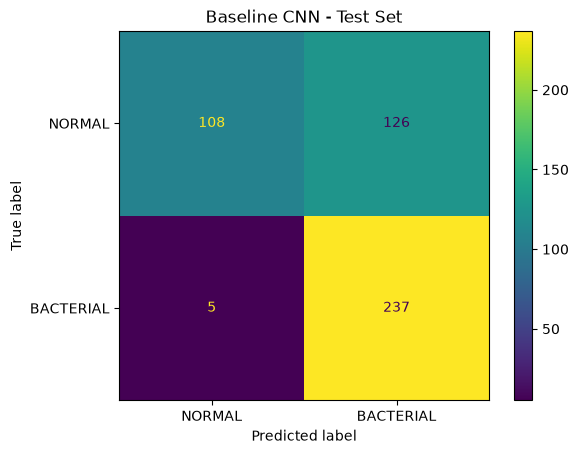


Regularized CNN
[[163  71]
 [  4 238]]


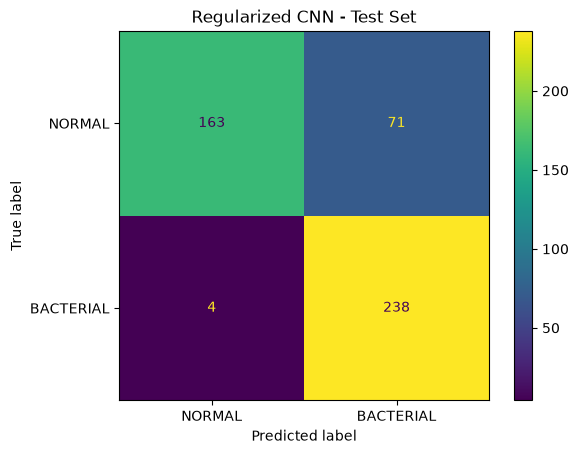


Deeper CNN
[[115 119]
 [  3 239]]


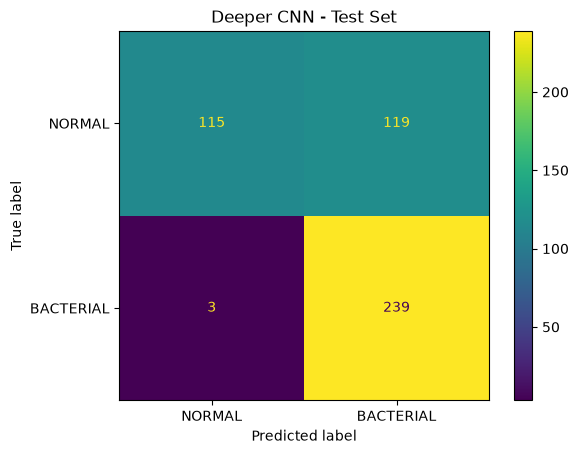

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline CNN,0.725,0.653,0.979,0.783,0.937
1,Regularized CNN,0.842,0.770,0.983,0.864,0.974
2,Deeper CNN,0.744,0.668,0.988,0.797,0.949


In [27]:
# Get CNN test metrics and confusion matrices
DNN_test_results = []

for name, model in zip(model_names, DNN_model_list):

    # Predicted probabilities
    y_prob = model.predict(X_test, verbose=0).ravel()

    # Convert probabilities to class predictions
    y_pred = (y_prob >= 0.5).astype(int)

    results = {
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "F1": round(f1_score(y_test, y_pred), 3),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 3)
    }

    DNN_test_results.append(results)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["NORMAL", "BACTERIAL"]
    )

    disp.plot()
    plt.title(f"{name} - Test Set")
    plt.show()


DNN_test_results_df = pd.DataFrame(DNN_test_results)

DNN_test_results_df

In [28]:
final_svm_results = pd.DataFrame([{
    "Model": "Final SVM",
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_score)
}])

final_comparison_df = pd.concat([
    final_svm_results,
    DNN_test_results_df[
        DNN_test_results_df["Model"] == "Regularized CNN"
    ]
], ignore_index=True).round(3)

final_comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Final SVM,0.800,0.725,0.979,0.833,0.966
1,Regularized CNN,0.842,0.770,0.983,0.864,0.974


In [29]:
# Save models
saved_models_dir = Path("saved_models")
saved_models_dir.mkdir(exist_ok=True)

# Save final SVM
joblib.dump(
    best_model,
    saved_models_dir / "final_SVM.joblib"
)

# Save final CNN
regularized_CNN_model.save(
    saved_models_dir / "final_regularized_CNN.keras"
)

print("Saved models:")
for file in saved_models_dir.iterdir():
    print(f" - {file}")

print("Final models saved successfully.")

print('-' * 60)

notebook_end = time.perf_counter()

elapsed_seconds = notebook_end - notebook_start

print(f"Notebook execution time: {elapsed_seconds:.2f} seconds")
print(f"Notebook execution time: {elapsed_seconds / 60:.2f} minutes")

Saved models:
 - saved_models\final_regularized_CNN.keras
 - saved_models\final_SVM.joblib
Final models saved successfully.
------------------------------------------------------------
Notebook execution time: 4401.72 seconds
Notebook execution time: 73.36 minutes
